# DiCE tests for "heart disease" data and models

In [1]:
from aiwhatif_cf.dice_pipeline.config import DicePipelineConfig

config = DicePipelineConfig()
print(config)

data dir path ok:         True
model dir path ok:        True
CF outputs dir path ok:   True
target_bp              : hltprhb
target_hc              : hltprhc
cf_output_dir          : /home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests/cf_outputs
feature_cols           : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'gndr', 'dosprt']
immutable_cols         : ['gndr']
continuous_features    : ['bmi']
backend                : sklearn
model_type             : classifier
explainer_method       : random
stopping_threshold     : 0.5
posthoc_sparsity_param : 0.1
target_factor          : 0.5
cf_random_seed         : 111
train_data_path_bp     : /home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests/data/05_single_target/ess_ready_v2_hltprhb_train.csv
train_data_path_hc     : /home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests/data/05_single_target/ess_ready_v2_hltprhc_train.csv
test_da

In [2]:
# extracts paths (varies from notebooks)
TARGET          = config.target_hc
TRAIN_DATA_PATH = config.train_data_path_hc
TEST_DATA_PATH  = config.test_data_path_hc
MODEL_PATH      = config.model_path_hc
CF_OUTPUTS_DIR  = config.cf_output_dir

# loading data

In [3]:
import pandas as pd

train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

In [4]:
train_df.head()

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhc
0,3.0,3.0,6.0,3.0,2.0,0,36.921078,1,0.0,0
1,2.0,3.0,6.0,4.0,1.0,0,22.386314,1,7.0,0
2,4.0,4.0,6.0,6.0,1.0,0,30.846277,2,1.0,0
3,3.0,2.0,5.0,3.0,2.0,0,23.323418,1,7.0,0
4,3.0,2.0,4.0,2.0,2.0,0,30.110279,2,7.0,0


In [5]:
train_df.describe()

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhc
count,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000
mean,3.221756,3.151720,4.357997,4.625855,1.775385,0.045099,25.914304,1.524161,3.162455,0.113585
std,1.310048,1.110769,1.828497,2.042445,0.830707,0.207525,4.151558,0.499423,2.593593,0.317311
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,16.003658,1.000000,0.000000,0.000000
25%,2.000000,2.000000,3.000000,3.000000,1.000000,0.000000,22.862534,1.000000,0.000000,0.000000
50%,3.000000,3.000000,5.000000,5.000000,2.000000,0.000000,25.535446,2.000000,3.000000,0.000000
75%,4.000000,4.000000,6.000000,7.000000,2.000000,0.000000,28.393726,2.000000,5.000000,0.000000
max,7.000000,7.000000,6.000000,7.000000,4.000000,1.000000,40.000000,2.000000,7.000000,1.000000


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32883 entries, 0 to 32882
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   etfruit   32883 non-null  float64
 1   eatveg    32883 non-null  float64
 2   cgtsmok   32883 non-null  float64
 3   alcfreq   32883 non-null  float64
 4   slprl     32883 non-null  float64
 5   paccnois  32883 non-null  int64  
 6   bmi       32883 non-null  float64
 7   gndr      32883 non-null  int64  
 8   dosprt    32883 non-null  float64
 9   hltprhc   32883 non-null  int64  
dtypes: float64(7), int64(3)
memory usage: 2.5 MB


### checking class distribution of datasets

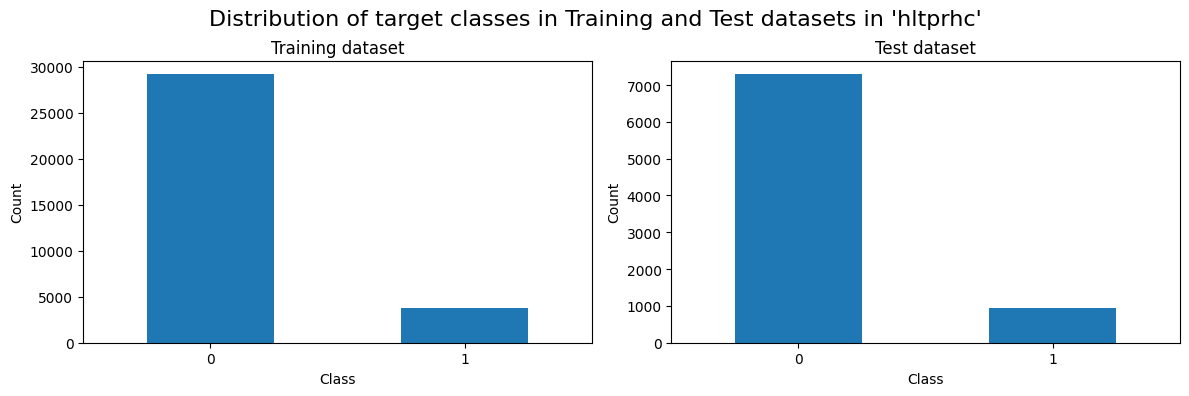

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
datasets = [("Training", train_df), ("Test", test_df)]

for ax, (name, df) in zip(axes, datasets):
    df[TARGET].value_counts().plot(kind="bar", ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_title(f"{name} dataset")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

fig.suptitle(f"Distribution of target classes in Training and Test datasets in '{TARGET}'", fontsize=16)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


# load and inspect predictor model

that the models features and importances seem to match what the later 
counterfactual models recommend.

In [8]:
import joblib

rf_model = joblib.load(MODEL_PATH)
print("Loaded model:", MODEL_PATH)

importances = rf_model.feature_importances_
model_features = rf_model.feature_names_in_

print("feature names in model: ", model_features)

Loaded model: /home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests/models/rf_hltprhc_2026-03-26.pkl
feature names in model:  ['etfruit' 'eatveg' 'cgtsmok' 'alcfreq' 'slprl' 'paccnois' 'bmi' 'gndr'
 'dosprt']


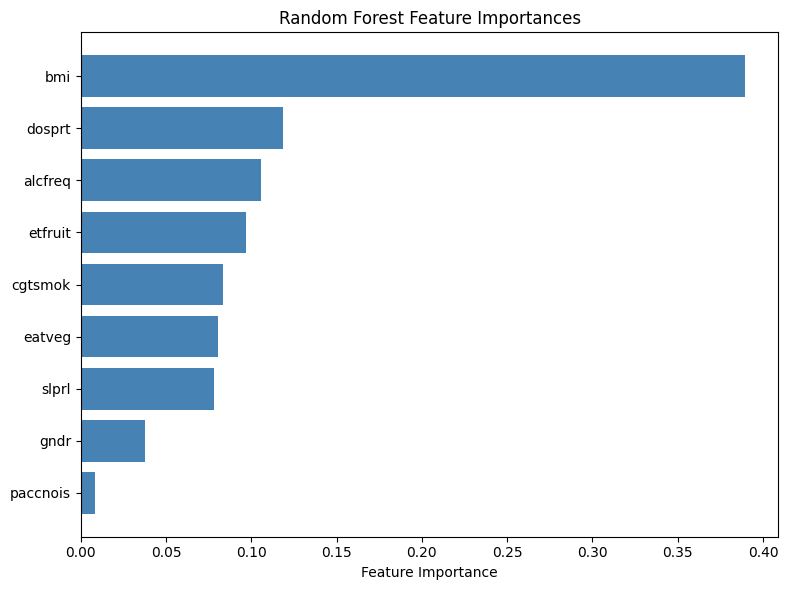

In [9]:
import numpy as np

idx = np.argsort(importances)
sorted_features = model_features[idx]
sorted_importances = importances[idx]

plt.figure(figsize=(8, 6))
plt.barh(sorted_features, sorted_importances, color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()


# defining features

In [10]:
print("data features == model features: ", config.feature_cols == model_features)
print("Immutable: ", config.immutable_cols)
print("features_to_vary: ", config.features_to_vary)

data features == model features:  [ True  True  True  True  True  True  True  True  True]
Immutable:  ['gndr']
features_to_vary:  ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']


In [11]:
from aiwhatif_cf.dice_pipeline.risk import RiskEvaluator

risk_evaluator = RiskEvaluator(
    model=rf_model,   # for now, sklearn classifer models...
    feature_cols=config.feature_cols,
    target_factor=config.target_factor, # 0.5
)


# Create the DiCE-objects with test data

In [12]:
import dice_ml

dice_data = dice_ml.Data(
    dataframe=test_df,
    continuous_features=config.continuous_features, # bmi
    outcome_name=TARGET
)

print(dice_data)
print(type(dice_data))
print(dice_data.__dir__())

<class 'dice_ml.data_interfaces.public_data_interface.PublicData'>
['outcome_name', 'data_df', 'continuous_feature_names', 'feature_names', 'number_of_features', 'categorical_feature_names', 'categorical_feature_indexes', 'continuous_features_precision', 'permitted_range', 'data_name', '__module__', '__doc__', '__init__', '_validate_and_set_dataframe', '_validate_and_set_continuous_features', '_validate_and_set_continuous_features_precision', '_set_feature_dtypes', 'get_features_range', 'get_data_type', 'one_hot_encode_data', 'normalize_data', 'de_normalize_data', 'get_valid_feature_range', 'get_minx_maxx', 'get_mads', 'get_valid_mads', 'get_quantiles_from_training_data', 'create_ohe_params', 'get_data_params_for_gradient_dice', 'get_encoded_categorical_feature_indexes', 'get_indexes_of_features_to_vary', 'fit_label_encoders', 'from_label', 'from_dummies', 'get_decimal_precisions', 'get_decoded_data', 'prepare_df_for_ohe_encoding', 'prepare_query_instance', 'get_ohe_min_max_normalized_

In [13]:
dice_model = dice_ml.Model(
    model=rf_model,
    backend=config.backend,         # sklearn
    model_type=config.model_type,   # classifier
)

print(dice_model)
print(type(dice_model))
print(dice_model.__dir__())

<class 'dice_ml.model_interfaces.base_model.BaseModel'>
['model_type', 'model', 'model_path', 'backend', 'transformer', '__module__', '__init__', 'load_model', 'get_output', 'get_gradient', 'get_num_output_nodes', 'get_num_output_nodes2', '__dict__', '__weakref__', '__doc__', '__new__', '__repr__', '__hash__', '__str__', '__getattribute__', '__setattr__', '__delattr__', '__lt__', '__le__', '__eq__', '__ne__', '__gt__', '__ge__', '__reduce_ex__', '__reduce__', '__getstate__', '__subclasshook__', '__init_subclass__', '__format__', '__sizeof__', '__dir__', '__class__']


In [14]:
# integrate data and dice model into explainer
# random method = standard?
explainer = dice_ml.Dice(
    dice_data,
    dice_model,
    method=config.explainer_method, # random
)

print(explainer)
print(type(explainer))
print(explainer.__dir__())

<class 'dice_ml.explainer_interfaces.dice_random.DiceRandom'>
['data_interface', 'model', 'precisions', 'outcome_precision', '__module__', '__init__', '_generate_counterfactuals', 'get_samples', 'get_continuous_samples', '__doc__', '__abstractmethods__', '_abc_impl', '_find_features_having_missing_values', '_validate_counterfactual_configuration', 'generate_counterfactuals', 'setup', 'check_query_instance_validity', 'local_feature_importance', 'global_feature_importance', 'feature_importance', 'predict_fn', 'predict_fn_for_sparsity', 'do_posthoc_sparsity_enhancement', 'do_linear_search', 'do_binary_search', 'misc_init', 'infer_target_cfs_class', 'infer_target_cfs_range', 'decide_cf_validity', 'is_cf_valid', 'decode_model_output', 'get_model_output_from_scores', 'check_permitted_range', 'sigmoid', 'build_KD_tree', 'round_to_precision', '_check_any_counterfactuals_computed', 'decode_to_original_labels', 'serialize_explainer', 'deserialize_explainer', '__dict__', '__weakref__', '__slots__

# Select datapoints to test and generate CF

In [15]:
positives = test_df[test_df[TARGET] == 1]
positives.head(20)

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhc
4,3.0,3.0,5.0,6.0,2.0,0,28.344671,1,0.0,1
10,4.0,4.0,6.0,7.0,3.0,0,28.125000,2,0.0,1
26,3.0,3.0,5.0,3.0,1.0,0,23.040020,2,3.0,1
30,3.0,3.0,4.0,7.0,3.0,0,31.615793,1,0.0,1
43,6.0,3.0,1.0,1.0,3.0,0,22.222222,2,6.0,1
52,3.0,3.0,6.0,3.0,2.0,0,31.141869,1,6.0,1
54,3.0,4.0,6.0,7.0,2.0,0,24.221453,2,0.0,1
58,5.0,5.0,6.0,7.0,2.0,0,24.435187,2,5.0,1
62,4.0,3.0,4.0,2.0,2.0,0,23.243802,1,7.0,1
65,2.0,3.0,6.0,7.0,3.0,0,26.171875,2,0.0,1


Selected indexes to test:
- [4]  normal BMI (~28.3), middlehigh values
- [43] very low alcohol (1), very low smoking (1), high dosprt (6), BMI ~22.2
- [77] high etfruit (7) & eatveg (5), paccnois=1, BMI ~30.85
- [143] high BMI (~36.23), low cgtsmok (1), high dosprt (7)
- [153] very low BMI (~19.14), low dosprt (0), high health (4)

In [16]:
selected_indices = [4, 43, 77, 143, 153]

query_instances = test_df.loc[selected_indices][config.feature_cols]
query_instances

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt
4,3.0,3.0,5.0,6.0,2.0,0,28.344671,1,0.0
43,6.0,3.0,1.0,1.0,3.0,0,22.222222,2,6.0
77,7.0,5.0,4.0,6.0,1.0,1,30.853994,2,1.0
143,3.0,3.0,1.0,6.0,2.0,0,36.227509,1,7.0
153,3.0,3.0,4.0,6.0,3.0,0,19.135802,1,0.0


In [17]:
print(config.features_to_vary)

['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']


In [18]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


cf_result = explainer.generate_counterfactuals(
        query_instances=query_instances, # could be multiple!
        total_CFs=3,
        desired_class=0,      # or opposite?

        desired_range=None,   # for regression problems
        permitted_range=None, # dict with feat_names as keys, and p-range as list

        features_to_vary=config.features_to_vary,
        stopping_threshold=0.9,         # config.stopping_threshold, # 0.5

        #### weights and post-hoc config - random model does not accept proximity etc...
        # proximity_weight=None,        # pos float: Larger this weight, more close the counterfactuals are to the query_instance. Used by ['genetic', 'gradientdescent'],
        # sparsity_weight=None,         # pos float: Larger this weight, less features are changed from the query_instance. IGNORED by random
        # diversity_weight=None,        # pos float: Larger this weight, more diverse the counterfactuals are.  IGNORED by random
        # categorical_penalty=None,     # pos float: A weight to ensure that all levels of a categorical variable sums to 1. IGNORED by random
        # sample_size

        posthoc_sparsity_param=0.1,     # Parameter for the post-hoc operation on continuous features to enhance sparsity.
        posthoc_sparsity_algorithm="linear", # Perform either linear or binary search.

        # other
        verbose=True,
        random_seed=config.cf_random_seed
)


 20%|██        | 1/5 [00:00<00:01,  2.33it/s]

Diverse Counterfactuals found! total time taken: 00 min 00 sec


 40%|████      | 2/5 [00:00<00:01,  2.31it/s]

Diverse Counterfactuals found! total time taken: 00 min 00 sec


 60%|██████    | 3/5 [00:01<00:00,  2.31it/s]

Diverse Counterfactuals found! total time taken: 00 min 00 sec


 80%|████████  | 4/5 [00:01<00:00,  2.34it/s]

Diverse Counterfactuals found! total time taken: 00 min 00 sec


100%|██████████| 5/5 [00:02<00:00,  2.32it/s]

Diverse Counterfactuals found! total time taken: 00 min 00 sec


# Annoting CF with risk:

In [19]:
cf_result.cf_examples_list

In [20]:
print(dir(cf_result.cf_examples_list[0]))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_dump_output', '_visualize_internal', 'data_interface', 'desired_class', 'desired_range', 'display_df', 'final_cfs_df', 'final_cfs_df_sparse', 'final_cfs_list', 'from_json', 'model_type', 'new_outcome', 'posthoc_sparsity_param', 'print_list', 'test_instance_df', 'test_pred', 'to_json', 'visualize_as_dataframe', 'visualize_as_list']


In [21]:
query_instances


,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt
4,3.0,3.0,5.0,6.0,2.0,0,28.344671,1,0.0
43,6.0,3.0,1.0,1.0,3.0,0,22.222222,2,6.0
77,7.0,5.0,4.0,6.0,1.0,1,30.853994,2,1.0
143,3.0,3.0,1.0,6.0,2.0,0,36.227509,1,7.0
153,3.0,3.0,4.0,6.0,3.0,0,19.135802,1,0.0


In [22]:
cf_df = cf_result.cf_examples_list[0].final_cfs_df.copy()
cf_df

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhc
0,3.0,3.0,5.0,6.0,2.0,0,22.571846,1,0.0,0
1,5.0,3.0,5.0,6.0,2.0,0,34.832927,1,0.0,0
2,3.0,3.0,5.0,6.0,2.0,0,24.284617,1,0.0,0


In [23]:
from aiwhatif_cf.dice_pipeline.risk import RiskEvaluator

risk_evaluator = RiskEvaluator(
    model=rf_model,   # for now, sklearn classifer models...
    feature_cols=config.feature_cols,
    target_factor=config.target_factor, # 0.5
)


In [24]:
query_instance = query_instances.loc[[4]]

cf_risk_annoted = risk_evaluator.annotate(
    query_original=query_instance,
    counterfactuals=cf_df,
)

cf_risk_annoted

,query_index,cf_id,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhc,original_risk,target_risk,predicted_risk,meets_target_risk
0,4,cf_0,3.0,3.0,5.0,6.0,2.0,0,22.571846,1,0.0,0,0.125486,0.062743,0.153222,False
1,4,cf_1,5.0,3.0,5.0,6.0,2.0,0,34.832927,1,0.0,0,0.125486,0.062743,0.103032,False
2,4,cf_2,3.0,3.0,5.0,6.0,2.0,0,24.284617,1,0.0,0,0.125486,0.062743,0.152887,False


In [25]:
from aiwhatif_cf.dice_pipeline.recommendations import DiceRecommender

recommender = DiceRecommender(
    feature_cols=config.feature_cols,
    target=TARGET,
    data_filename=TEST_DATA_PATH.name,
)

recommendations = recommender.get_recommendations(
    original=query_instance,
    annoted_counterfactuals=cf_risk_annoted,
)

recommendations

[{'query_index': 4,
  'cf_id': 'cf_0',
  'original_risk': 0.1254864454900266,
  'target_risk': 0.0627432227450133,
  'predicted_risk': 0.1532219136980551,
  'meets_target_risk': False,
  'changes': [('bmi', 28.344671201814062, 22.571846)]},
 {'query_index': 4,
  'cf_id': 'cf_1',
  'original_risk': 0.1254864454900266,
  'target_risk': 0.0627432227450133,
  'predicted_risk': 0.10303173941576499,
  'meets_target_risk': False,
  'changes': [('etfruit', 3.0, 5.0), ('bmi', 28.344671201814062, 34.832927)]},
 {'query_index': 4,
  'cf_id': 'cf_2',
  'original_risk': 0.1254864454900266,
  'target_risk': 0.0627432227450133,
  'predicted_risk': 0.15288749388308315,
  'meets_target_risk': False,
  'changes': [('bmi', 28.344671201814062, 24.284617)]}]

In [26]:
formatted_rec = recommender.format_recommendations(
    query_instance,
    recommendations,
    true_outcome = test_df.loc[query_instance.index, TARGET]
)

print(formatted_rec)

Task / Target: hltprhc
Data filename: ess_ready_v2_hltprhc_test.csv
Selected query instance (index 4):

 etfruit  eatveg  cgtsmok  alcfreq  slprl  paccnois       bmi  gndr  dosprt
     3.0     3.0      5.0      6.0    2.0         0 28.344671     1     0.0

Original predicted risk (P(hltprhc=4    1
Name: hltprhc, dtype: int64)): 0.1255
Target-risk threshold: 0.0627

=== Changes per Counterfactual (vs Original) ===

--- cf_0 ---
Predicted risk: 0.1532
Meets target:   False
Changes:
  - bmi: 28.345 → 22.572

--- cf_1 ---
Predicted risk: 0.1030
Meets target:   False
Changes:
  - etfruit: 3.000 → 5.000
  - bmi: 28.345 → 34.833

--- cf_2 ---
Predicted risk: 0.1529
Meets target:   False
Changes:
  - bmi: 28.345 → 24.285



### Batch annotation

In [27]:
rows = []

for i, (idx, original_row) in enumerate(zip(selected_indices, query_instances.to_dict("records"))):

    # Convert original row to DataFrame
    original_df = pd.DataFrame([original_row])

    # Extract CFs for this instance
    cf_df = cf_result.cf_examples_list[i].final_cfs_df.copy()

    # Annotate CFs with risk information
    cf_risk = risk_evaluator.annotate(original_df, cf_df)

    # Extract original + target risk (same for all CFs)
    original_risk = cf_risk["original_risk"].iloc[0]
    target_risk = cf_risk["target_risk"].iloc[0]

    # Extract outcome value for original instance
    outcome_col = TARGET
    outcome_value = test_df.loc[idx, TARGET]

    # --- ORIGINAL ROW ---
    # Create a full row with the same columns as CF rows
    orig_row = {col: None for col in cf_risk.columns}

    # Insert feature values
    for col, val in original_row.items():
        orig_row[col] = val

    # Insert metadata
    orig_row["query_index"] = idx
    orig_row["cf_id"] = "original"

    # Insert correct risk values
    orig_row["original_risk"] = original_risk
    orig_row["target_risk"] = target_risk

    # Insert outcome
    orig_row[outcome_col] = outcome_value

    rows.append(orig_row)

    # --- CF ROWS ---
    for j, row in cf_risk.iterrows():
        cf_row = row.to_dict()
        cf_row["query_index"] = idx
        cf_row["cf_id"] = f"cf_{j+1}"
        rows.append(cf_row)

# Build final DataFrame
annotated_batch = pd.DataFrame(rows)

# Move query_index and cf_id first
first_cols = ["query_index", "cf_id"]
other_cols = [c for c in annotated_batch.columns if c not in first_cols]
annotated_batch = annotated_batch[first_cols + other_cols]


In [28]:
annotated_batch

,query_index,cf_id,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhc,original_risk,target_risk,predicted_risk,meets_target_risk
0,4,original,3.0,3.0,5.0,6.0,2.0,0,28.344671,1,0.0,1,0.125486,0.062743,NaN,None
1,4,cf_1,3.0,3.0,5.0,6.0,2.0,0,22.571846,1,0.0,0,0.125486,0.062743,0.153222,False
2,4,cf_2,5.0,3.0,5.0,6.0,2.0,0,34.832927,1,0.0,0,0.125486,0.062743,0.103032,False
3,4,cf_3,3.0,3.0,5.0,6.0,2.0,0,24.284617,1,0.0,0,0.125486,0.062743,0.152887,False
4,43,original,6.0,3.0,1.0,1.0,3.0,0,22.222222,2,6.0,1,0.089316,0.044658,NaN,None
5,43,cf_1,6.0,3.0,1.0,7.0,3.0,0,22.222222,2,6.0,0,0.089316,0.044658,0.154534,False
6,43,cf_2,6.0,3.0,1.0,1.0,3.0,0,31.616419,2,6.0,0,0.089316,0.044658,0.142638,False
7,43,cf_3,6.0,3.0,1.0,1.0,3.0,0,28.026098,2,4.0,0,0.089316,0.044658,0.116151,False
8,77,original,7.0,5.0,4.0,6.0,1.0,1,30.853994,2,1.0,1,0.163228,0.081614,NaN,None
9,77,cf_1,7.0,5.0,4.0,6.0,1.0,1,36.152238,2,1.0,0,0.163228,0.081614,0.166202,False


In [29]:
all_recommendations = []

for idx in selected_indices:
    # 1. Extract original instance
    query_instance = query_instances.loc[[idx]]

    # 2. Extract CFs for this instance
    cf_df = cf_result.cf_examples_list[selected_indices.index(idx)].final_cfs_df.copy()

    # 3. Annotate CF risks
    cf_risk_annoted = risk_evaluator.annotate(query_instance, cf_df)

    # 4. Generate recommendations
    recs = recommender.get_recommendations(
        original=query_instance,
        annoted_counterfactuals=cf_risk_annoted,
    )

    # 5. Store everything for export
    all_recommendations.append({
        "query_index": idx,
        "cf_recs": recs
    })

In [33]:
import datetime as dt
from sklearn.metrics import classification_report

# --- Prepare output directory ---
today = dt.datetime.today().strftime("%Y-%m-%d")
output_dir = CF_OUTPUTS_DIR / f"DiCE_{today}_{TARGET}"
output_dir.mkdir(parents=True, exist_ok=True)

# --- Save train and test data and annotated CF batch ---
train_df.to_csv(output_dir / TRAIN_DATA_PATH.name, index=False)
test_df.to_csv(output_dir / TEST_DATA_PATH.name, index=False)
annotated_batch.to_csv(output_dir / f"DiCE_annotated_{TARGET}.csv", index=False)

# --- Save config  ---
config_path = output_dir / f"DiCE_config_{TARGET}.txt"
with open(config_path, "w", encoding="utf-8") as f:
    f.write("=== CONFIGURATION ===\n\n")
    f.write(str(config))   # relies on __str__()
    f.write("\n\n")

# --- Save recommendations ---
rec_path = output_dir / f"DiCE_recommendations_{TARGET}.txt"
with open(rec_path, "w", encoding="utf-8") as f:
    f.write("=== RECOMMENDATIONS ===\n\n")

    for rec in all_recommendations:
        qidx = rec["query_index"]
        true_y = test_df.loc[qidx, TARGET]

        formatted = recommender.format_recommendations(
            query_instance=query_instances.loc[[qidx]],
            recs=rec["cf_recs"],
            true_outcome=true_y
        )
        f.write(formatted)
        f.write("\n\n" + "="*80 + "\n\n")

# --- Save model parameters + performance ---
rf_info_path = output_dir / f"rf_{TARGET}_info.txt"

# Compute predictions on test set
y_true = test_df[TARGET]
y_pred = rf_model.predict(test_df[config.feature_cols])

report = classification_report(y_true, y_pred)

with open(rf_info_path, "w", encoding="utf-8") as f:
    f.write("=== RANDOM FOREST PARAMETERS ===\n\n")
    for k, v in rf_model.get_params().items():
        f.write(f"{k}: {v}\n")

    f.write("\n\n=== MODEL PERFORMANCE (TEST SET) ===\n\n")
    f.write(report)
